In [1]:
import torax
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

17:04:15 CRITICAL Could not import 'imas_core': No module named 'imas_core'. Some functionality is not available. @imas_interface.py:34
2026-02-19 17:04:15,755 [CRITICAL] Could not import 'imas_core': No module named 'imas_core'. Some functionality is not available.


In [2]:
CONFIG = {
    'plasma_composition': {
        'main_ion': {'D': 0.5, 'T': 0.5},  # (bundled isotope average)
        'impurity': 'Ne',
        'Z_eff': 1.6,  # sets impurity density
    },
    'profile_conditions': {
        'Ip': {0: 3e6, 80: 10.5e6},  # total plasma current in A
        # boundary + initial conditions for T and n
        # initial condition ion temperature for r=0 and r=a_minor
        'T_i': {0.0: {0.0: 6.0, 1.0: 0.1}},
        'T_i_right_bc': 0.1,  # boundary condition ion temperature for r=a_minor
        # initial condition electron temperature for r=0 and r=a_minor
        'T_e': {0.0: {0.0: 6.0, 1.0: 0.1}},
        'T_e_right_bc': 0.1,  # boundary condition electron temp for r=a_minor
        'n_e_right_bc_is_fGW': True,
        # boundary condition density for r=a_minor
        'n_e_right_bc': {0: 0.1, 80: 0.3},
        # set initial condition density according to Greenwald fraction.
        'n_e_nbar_is_fGW': True,
        'nbar': 1,
        'n_e': {0: {0.0: 1.5, 1.0: 1.0}},  # Initial electron density profile
    },
    'numerics': {
        # simulation control
        't_final': 80,  # length of simulation time in seconds
        'fixed_dt': 2,
        # 1/multiplication factor for sigma (conductivity) to reduce current
        # diffusion timescale to be closer to heat diffusion timescale.
        'resistivity_multiplier': 1,
        'evolve_ion_heat': True,
        'evolve_electron_heat': True,
        'evolve_current': True,
        'evolve_density': True,
        'max_dt': 0.5,
        # multiplier in front of the base timestep dt=dx^2/(2*chi). Can
        # likely be increased further beyond this default.
        'chi_timestep_prefactor': 30,
        'dt_reduction_factor': 3,
    },
    'geometry': {
        'geometry_type': 'chease',
        'geometry_file': 'iterhybrid.mat2cols',
        'Ip_from_parameters': True,
        'R_major': 6.2,  # major radius (R) in meters
        'a_minor': 2.0,  # minor radius (a) in meters
        'B_0': 5.3,  # Toroidal magnetic field on axis [T]
    },
    'neoclassical': {
        'bootstrap_current': {
            'bootstrap_multiplier': 1.0,
        },
    },
    'sources': {
        # Current sources (for psi equation)
        'generic_current': {
            # total "external" current fraction
            'fraction_of_total_current': 0.15,
            # width of "external" Gaussian current profile (normalized radial
            # coordinate)
            'gaussian_width': 0.075,
            # radius of "external" Gaussian current profile (normalized radial
            # coordinate)
            'gaussian_location': 0.36,
        },
        # Electron density sources/sink (for the n_e equation).
        'generic_particle': {
            # total particle source
            'S_total': 0.0,
            # particle source Gaussian central location (normalized radial
            # coordinate)
            'deposition_location': 0.3,
            # particle source Gaussian width (normalized radial coordinate)
            'particle_width': 0.25,
        },
        'gas_puff': {
            # pellets behave like a gas puff for this simulation with
            # exponential decay therefore use the puff structure for pellets
            # exponential decay length of gas puff ionization (normalized radial
            # coordinate)
            'puff_decay_length': 0.3,
            # total pellet particles/s
            'S_total': 0.0,
        },
        'ohmic': {},
        'pellet': {
            # total pellet particles/s (continuous pellet model)
            'S_total': 0.0e22,
            # Gaussian width of pellet deposition (normalized radial coordinate)
            # in continuous pellet model
            'pellet_width': 0.1,
            # Pellet source Gaussian central location (normalized radial
            # coordinate) in continuous pellet model.
            'pellet_deposition_location': 0.85,
        },
        # Ion and electron heat sources (for the temp-ion and temp-el eqs).
        'generic_heat': {
            'gaussian_location': 0.12741589640723575,
            # Gaussian width in normalized radial coordinate r
            'gaussian_width': 0.07280908366127758,
            # total heating (including accounting for radiation) r
            'P_total': 20.0e6,
            # electron heating fraction r
            'electron_heat_fraction': 1.0,
        },
        'fusion': {},
        'ei_exchange': {
            # multiplier for ion-electron heat exchange term for sensitivity
            'Qei_multiplier': 1.0,
        },
    },
    'pedestal': {
        'model_name': 'set_T_ped_n_ped',
        'set_pedestal': True,
        'T_i_ped': 1.0,  # ion pedestal top temperature in keV for T_i
        'T_e_ped': 1.0,  # electron pedestal top temperature in keV for T_e
        'n_e_ped_is_fGW': True,
        # pedestal top electron density in units of fGW
        'n_e_ped': {0: 0.3, 80: 0.7},
        'rho_norm_ped_top': 0.9,  # set ped top location in normalized radius
    },
    'transport': {
        'model_name': 'qlknn',
        # set inner core transport coefficients (ad-hoc MHD/EM transport)
        'apply_inner_patch': True,
        'D_e_inner': 0.25,
        'V_e_inner': 0.0,
        'chi_i_inner': 1.5,
        'chi_e_inner': 1.5,
        'rho_inner': 0.3,  # radius below which patch transport is applied
        # set outer core transport coefficients (L-mode near edge region)
        'apply_outer_patch': True,
        'D_e_outer': 0.1,
        'V_e_outer': 0.0,
        'chi_i_outer': 2.0,
        'chi_e_outer': 2.0,
        'rho_outer': 0.9,  # radius above which patch transport is applied
        # allowed chi and diffusivity bounds
        'chi_min': 0.05,  # minimum chi
        'chi_max': 100,  # maximum chi (can be helpful for stability)
        'D_e_min': 0.05,  # minimum electron diffusivity
        'D_e_max': 50,  # maximum electron diffusivity
        'V_e_min': -10,  # minimum electron convection
        'V_e_max': 10,  # minimum electron convection
        'smoothing_width': 0.1,
        # qlknn params.
        'DV_effective': True,
        'include_ITG': True,  # to toggle ITG modes on or off
        'include_TEM': True,  # to toggle TEM modes on or off
        'include_ETG': True,  # to toggle ETG modes on or off
        # ensure that smag - alpha > -0.2 always, to compensate for no slab
        # modes
        'avoid_big_negative_s': True,
        # minimum |R/Lne| below which effective V is used instead of
        # effective D
        'An_min': 0.05,
        'ITG_flux_ratio_correction': 1,
    },
    'solver': {
        'solver_type': 'newton_raphson',
        'use_predictor_corrector': True,
        'n_corrector_steps': 10,
        # (deliberately) large heat conductivity for Pereverzev rule
        'chi_pereverzev': 30,
        # (deliberately) large particle diffusion for Pereverzev rule
        'D_pereverzev': 15,
        # use_pereverzev is only used for the linear solver
        'use_pereverzev': True,
        'log_iterations': False,
    },
    'time_step_calculator': {
        'calculator_type': 'fixed',
    },
}

In [3]:
torax_config = torax.ToraxConfig.from_dict(CONFIG)
data_tree, hist = torax.run_simulation(torax_config, log_timestep_info=False)

INFO:2026-02-19 17:04:15,962:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2026-02-19 17:04:15,962 [    INFO] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2026-02-19 17:04:16,279 [ WARNING] Falling back to legacy behavior as `profile_conditions.psi

In [4]:
# pull_torax_onto_psi function interpolates TORAX profiles from rho_toroidal to psi_norm grid
def pull_torax_onto_psi(data_tree, var_name, psi_N, time, load_into_state='results', normalize=False, profile_type='linterp'):
    r'''! Load TORAX variable onto psi_norm grid.
    @param data_tree TORAX output data tree.
    @param var_name Name of variable (e.g., 'T_i', 'j_ohmic', 'FFprime').
    @param time Time value to extract.
    @param load_into_state If 'state' loads into '_state', elif 'results' loads into '_results', elif None, return (psi, data).
    @param normalize If True, normalize profile: subtract edge value, divide by core value (for FFprime, pprime).
    @param profile_type Type key for returned dict: 'linterp' or 'jphi-linterp'. Default is 'linterp'.
    '''

    # Extract variable from profiles
    var = getattr(data_tree.profiles, var_name)
    var_data = var.sel(time=time, method='nearest').to_numpy()

    # Automatically detect which rho coordinate this variable uses
    if 'rho_cell_norm' in var.coords:
        grid = 'rho_cell_norm'
    elif 'rho_face_norm' in var.coords:
        grid = 'rho_face_norm'
    elif 'rho_norm' in var.coords:
        grid = 'rho_norm'
    else:
        raise ValueError(f"Variable {var_name} does not have a recognized rho coordinate")

    # Get rho_tor coordinate for this variable
    rho_tor = var.coords[grid].values

    # Get psi_norm on rho_face_norm grid and psi on rho_norm grid
    psi_norm_face = data_tree.profiles.psi_norm.sel(time=time, method='nearest').to_numpy()
    psi_rho_norm = data_tree.profiles.psi.sel(time=time, method='nearest').to_numpy()
    psi_norm_rho_norm = (psi_rho_norm - psi_rho_norm[0]) / (psi_rho_norm[-1] - psi_rho_norm[0])

    # Correct second element to avoid degeneracy from zero-gradient BC at core
    psi_norm_rho_norm[1] = (psi_norm_face[0] + psi_norm_face[1]) / 2.0

    # Convert psi to same grid as variable
    if grid == 'rho_cell_norm':
        psi_on_grid = psi_norm_rho_norm[1:-1]
    elif grid == 'rho_face_norm':
        psi_on_grid = psi_norm_face
    elif grid == 'rho_norm':
        psi_on_grid = psi_norm_rho_norm

    # Interpolate onto uniform psi grid
    data_on_psi = interp1d(psi_on_grid, var_data, kind='linear',
                        fill_value='extrapolate', bounds_error=False)(psi_N)


    # Normalize if requested
    if normalize:
        if grid == 'rho_cell_norm':
            # Cell-centered variables don't have a value at psi=0
            # Find the index in data_on_psi closest to the first cell center
            core_idx = np.argmin(np.abs(psi_N - psi_on_grid[0]))
            data_on_psi /= data_on_psi[core_idx]
        else:
            # Face or extended grid has actual core value at psi=0
            data_on_psi /= data_on_psi[0]

    if load_into_state == 'state':
        return {'x': psi_N.copy(), 'y': data_on_psi.copy(), 'type': profile_type}
    elif load_into_state == 'results':
        return data_on_psi.copy()
    else:
        return data_on_psi

In [17]:
# load tx dict
psi_N = np.linspace(0, 1, 100)
t=0
tx={
    'R': data_tree.scalars.R_major.sel(time=t, method='nearest'),
    # 'Z': data_tree.scalars.z_magnetic_axis.sel(time=t, method='nearest'),
    'B0': data_tree.scalars.B_0.sel(time=t, method='nearest'),
    'Ip': data_tree.scalars.Ip.sel(time=t, method='nearest'),
    'psi_axis': data_tree.profiles.psi.sel(time=t, method='nearest').to_numpy()[0]/(2*np.pi),
    'psi_lcfs': data_tree.profiles.psi.sel(time=t, method='nearest').to_numpy()[-1]/(2*np.pi),

    'q_prof': pull_torax_onto_psi(data_tree, 'q', psi_N, time=t),
    'q_axis': pull_torax_onto_psi(data_tree, 'q', psi_N, time=t)[0],
    'q_lcfs': pull_torax_onto_psi(data_tree, 'q', psi_N, time=t)[-1],

    'ffp_prof': pull_torax_onto_psi(data_tree, 'FFprime', psi_N, time=t),
    'pp_prof': pull_torax_onto_psi(data_tree, 'pprime', psi_N, time=t),
    'j_tot': pull_torax_onto_psi(data_tree, 'j_total', psi_N, time=t),

    'vol': pull_torax_onto_psi(data_tree, 'volume', psi_N, time=t),
    'vol_lcfs': data_tree.profiles.volume.sel(time=t, method='nearest').to_numpy()[-1],
    'vpr':    pull_torax_onto_psi(data_tree, 'vpr', psi_N, time=t),
    'R_inv_avg': pull_torax_onto_psi(data_tree, 'gm9', psi_N, time=t),

    'psi_N': pull_torax_onto_psi(data_tree, 'psi_norm', psi_N, time=t),
    'psi': pull_torax_onto_psi(data_tree, 'psi', psi_N, time=t) / (2.0 * np.pi),
    'psi_from_geo': pull_torax_onto_psi(data_tree, 'psi_from_geo', psi_N, time=t) / (2.0 * np.pi),
    'psi_from_Ip': pull_torax_onto_psi(data_tree, 'psi_from_Ip', psi_N, time=t) / (2.0 * np.pi),
}


t_idx = 0
time_val = 0
ds = data_tree["profiles"].ds
lcfs = ds.isel(time=t_idx).isel(rho_norm=-1)
R_out = float(lcfs["R_out"])          # outer midplane R
R_in  = float(lcfs["R_in"])           # inner midplane R
kappa = float(lcfs["elongation"])     # elongation
R0 = (R_out + R_in) / 2.0            # major radius at LCFS
a = (R_out - R_in) / 2.0             # minor radius at LCFS

# delta on face norm — select last face point for LCFS
delta_u = float(ds["delta_upper"].isel(time=t_idx).isel(rho_face_norm=-1))
delta_l = float(ds["delta_lower"].isel(time=t_idx).isel(rho_face_norm=-1))

print(f'B0 = {tx["B0"]:.3f} T, Ip = {tx["Ip"]:.3e} A')
print(f"R0 = {R0:.3f} m,  a = {a:.3f} m, kappa = {kappa:.3f}")
print(f'delta_upper = {delta_u:.3f}, delta_lower = {delta_l:.3f}')


B0 = 5.300 T, Ip = 3.000e+06 A
R0 = 6.202 m,  a = 1.989 m, kappa = 1.878
delta_upper = 0.383, delta_lower = 0.475


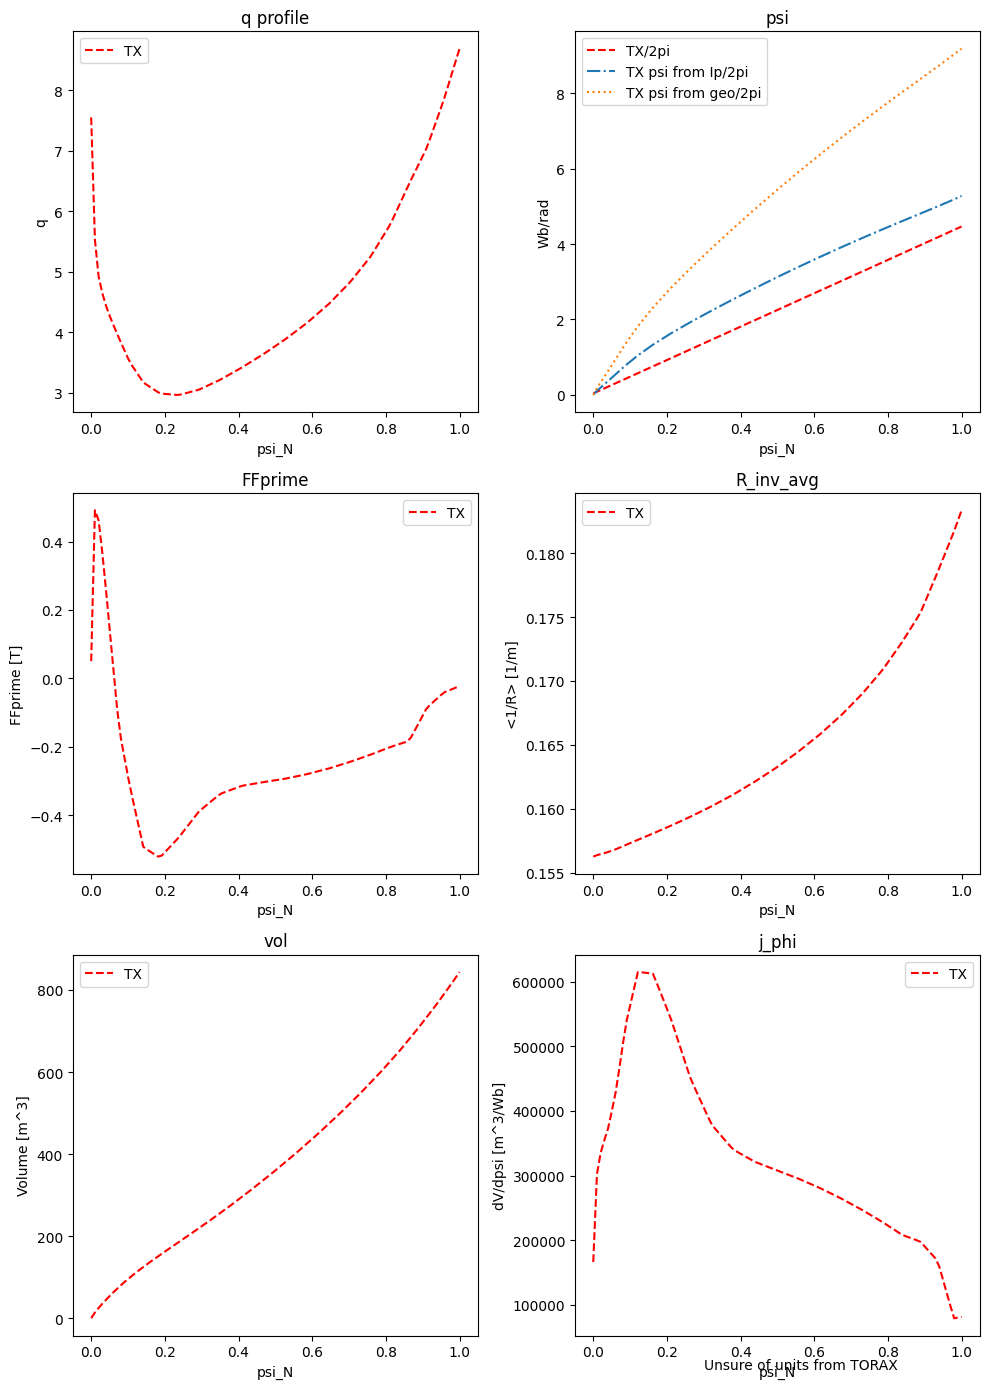

In [6]:
# Profile comparison plots
fig, axes = plt.subplots(3,2,figsize=(10,14))

ax00 = axes[0,0]
ax01 = axes[0,1]
ax10 = axes[1,0]
ax11 = axes[1,1]
ax20 = axes[2,0]
ax21 = axes[2,1]

ax00.set_title('q profile')
ax00.plot(tx['psi_N'], tx['q_prof'], 'r--', label='TX')
ax00.set_ylabel('q')
ax00.set_xlabel('psi_N')
ax00.legend()

ax01.set_title('psi')
ax01.plot(tx['psi_N'], tx['psi'], 'r--', label='TX/2pi')
ax01.plot(tx['psi_N'], tx['psi_from_Ip'], '-.', label = 'TX psi from Ip/2pi')
ax01.plot(tx['psi_N'], tx['psi_from_geo'], ':', label = 'TX psi from geo/2pi')
ax01.set_ylabel('Wb/rad')
ax01.set_xlabel('psi_N')
ax01.legend()

# ax10.set_title('R_avg')
# ax10.plot(tm['psi_N'], tm['R_avg'], label='eqdsk')
# ax10.plot(tx['psi_N'], tx['R_inv_avg'], 'r--', label='TX (not available)', alpha=0.3)
# ax10.legend()

ax10.set_title('FFprime')
ax10.plot(tx['psi_N'], tx['ffp_prof'], 'r--', label='TX')
ax10.set_ylabel('FFprime [T]')
ax10.set_xlabel('psi_N')
ax10.legend()

ax11.set_title('R_inv_avg')
ax11.plot(tx['psi_N'], tx['R_inv_avg'], 'r--', label='TX')
ax11.set_ylabel('<1/R> [1/m]')
ax11.set_xlabel('psi_N')
ax11.legend()

ax20.set_title('vol')
ax20.plot(tx['psi_N'], tx['vol'], 'r--', label='TX')
ax20.set_ylabel('Volume [m^3]')
ax20.set_xlabel('psi_N')
ax20.legend()

ax21.set_title('j_phi')
ax21.plot(tx['psi_N'], tx['j_tot'], 'r--', label='TX')
ax21.text(0.3,500, 'Unsure of units from TORAX')
ax21.set_ylabel('dV/dpsi [m^3/Wb]')
ax21.set_xlabel('psi_N')
ax21.legend()

fig.tight_layout()


TORAX:
R0 = 6.202 m, Z0 = 0.000 m, a = 1.989 m, kappa = 1.878
delta_upper = 0.383, delta_lower = 0.475
B0 = 5.300 T, Ip = 6.750e+06 A


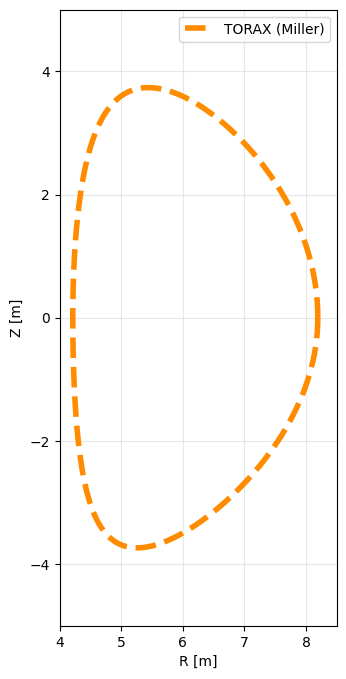

In [7]:
# extract geometry parameters from TORAX and construct LCFS using Miller geometry

ds = data_tree["profiles"].ds

t_idx = 0
time_val = 0

# --- Select LCFS (rho_norm = 1, i.e. last radial index) ---
lcfs = ds.isel(time=t_idx).isel(rho_norm=-1)

R_out = float(lcfs["R_out"])          # outer midplane R
R_in  = float(lcfs["R_in"])           # inner midplane R
kappa = float(lcfs["elongation"])     # elongation

# delta on face norm — select last face point for LCFS
delta_u = float(ds["delta_upper"].isel(time=t_idx).isel(rho_face_norm=-1))
delta_l = float(ds["delta_lower"].isel(time=t_idx).isel(rho_face_norm=-1))

# Derived geometric quantities
a = (R_out - R_in) / 2.0             # minor radius at LCFS
R0 = (R_out + R_in) / 2.0            # major radius at LCFS

# Z0 = float(dt["scalars"].ds["z_magnetic_axis"].isel(time=t_idx))
Z0 = 0

print(f"TORAX:")
print(f"R0 = {R0:.3f} m, Z0 = {Z0:.3f} m, a = {a:.3f} m, kappa = {kappa:.3f}")
print(f"delta_upper = {delta_u:.3f}, delta_lower = {delta_l:.3f}")
print(f'B0 = {tx["B0"]:.3f} T, Ip = {tx["Ip"]:.3e} A')

# Miller parameterization
# Upper half: theta in [0, pi],   uses delta_upper
# Lower half: theta in [pi, 2pi], uses delta_lower
theta_up = np.linspace(0, np.pi, 200)
theta_lo = np.linspace(np.pi, 2 * np.pi, 200)

def miller_R(theta, R0, a, delta):
    return R0 + a * np.cos(theta + np.arcsin(delta) * np.sin(theta))

def miller_Z(theta, a, kappa):
    return Z0 + kappa * a * np.sin(theta)


R_lcfs = np.concatenate([
    miller_R(theta_up, R0, a, delta_u),
    miller_R(theta_lo, R0, a, delta_l),
])
Z_lcfs = np.concatenate([
    miller_Z(theta_up, a, kappa),
    miller_Z(theta_lo, a, kappa),
])

# ax.plot(R_lcfs, Z_lcfs, "b-", linewidth=2)

# Compare LCFS boundaries from TokaMaker and TORAX
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_aspect('equal')
ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.set_ylim(-5,5)
ax.set_xlim(4,8.5)



# plot eqdsk geometry
ax.plot(R_lcfs, Z_lcfs, "--", color='darkorange', linewidth=4, label = 'TORAX (Miller)')

ax.legend()
ax.grid(True, alpha=0.3)